# Train/Test Supervised Machine Learning Classifiers

### Imports

In [1]:
# General
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import tabulate
import os

# Scikit-learn general
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)

# Image Analysis
from skimage.measure import label, regionprops

# ML Model
import xgboost as xgb

# Model and Data Preservation
import joblib
import json


# Set start time
start_time = time.time()

### Inputs

In [2]:
# Input the scan dimensions in microns of the training data scans
width_micron=1.0
height_micron=1.0

# Specify the path to the input folder (location of all files/data)
'''
This is the location where the processed AFM data files and feature list file
are saved.
'''
input_folder = "."


# Specify the path to the output folder (location to store saved files)
'''
This is the location in which the trained ML classifiers and list of
features used in the training will be saved.
'''
output_folder = "."


# Specify the filename of the .csv file of the list of features to be used in the training
'''
This is a .csv file containing the names of the features to be used
in the ML classifier training. The first column contains the
names of the engineered features (the same names as the
column headers in the processed AFM data .csv files).
'''
feature_list_filename = "features_list.csv"


# Specify the filename of the .csv file of the training data with particle/substrate only
'''
This is a .csv file containing the feature values for each
force-distance curve in the AFM scan of the PG particles on 
the MPBA/gold substrate. Each row is a different force-distance 
curve and each column is a different feature value.
'''
data_train_particles_filename = "training_particle_substrate_feature_values.csv"


# Specify the filename of the .csv file of the training data with bare substrate only
'''
This is a .csv file containing the feature values for each
force-distance curve in the AFM scan of the MPBA/gold substrate. 
Each row is a different force-distance 
curve and each column is a different feature value.
'''
data_train_substrate_filename = "training_substrate_only_feature_values.csv"


# Define font properties for all plots
font = {'size': 20, 'weight': 'normal'}
plt.rc('font', **font)

### Functions

In [3]:
# Define a function to plot the feature importance metrics
def plot_feature_importances(df, metric, title, color='lightblue'):
    # Normalize values for percentage display
    total_importance = df[metric].sum()
    df['Percentage'] = (df[metric] / total_importance) * 100  # Calculate percentage

    plt.figure(figsize=(15, 20))
    plt.barh(df['Feature'], df['Percentage'], color=color)
    plt.xlabel(f'Feature Importance (% of total {metric})')
    plt.title(f'Feature Importances ({title})')
    plt.gca().invert_yaxis()

    # Set x-axis limit
    max_val = df['Percentage'].max()
    plt.xlim(0, max_val * 1.2)

    # Add percentage annotations
    for index, percent in enumerate(df['Percentage']):
        plt.text(percent, index, f'{percent:.1f}%', va='center')

    plt.tight_layout()
    plt.show()
    
# Define a function to plot classification plots   
def plot_afm_classification(image_data, width_micron, height_micron, title = "AFM Image"):
    
    plt.figure(figsize=(10, 8))
    extent = [0, width_micron, 0, height_micron]  # [xmin, xmax, ymin, ymax]
    
    plt.imshow(image_data, cmap="gray", extent=extent)
    plt.xlabel("µm")
    plt.title(title)
    
    cbar = plt.colorbar(label="Classification")
    cbar.set_ticks([0, 1])
    
    plt.show()

### Import training/testing data for each force-distance curve

In [4]:
#----- Import Force-distance Curve data and manual labels -----#

# Read the .csv file into a DataFrame
file_path_data_train_particles = os.path.join(input_folder, data_train_particles_filename)
df_data_train_particles = pd.read_csv(file_path_data_train_particles)

# Read the .csv file into a DataFrame
file_path_data_train_substrate = os.path.join(input_folder, data_train_substrate_filename)
df_data_train_substrate = pd.read_csv(file_path_data_train_substrate)

# Combine the data from the two AFM measurements
df_all_data = pd.concat([df_data_train_particles, df_data_train_substrate])

### Import Feature List to Use

In [5]:
#----- Import list of features to use -----#

# Load the .csv file into a DataFrame
file_path_feature_list = os.path.join(input_folder, feature_list_filename)
features_selected_df_all = pd.read_csv(file_path_feature_list)
# Extract the first column (feature names)
features_selected_df = features_selected_df_all.iloc[:, [0]] 
# Convert the 'Feature' column to a list
selected_features = features_selected_df['Feature'].tolist()


# Display feature list information
print("Features loaded successfully as list:")
print(selected_features)
print('Number of selected features:', len(selected_features))

Features loaded successfully as list:
['Deformation from 2% to 5% of max force', 'Deformation from 2% to 25% of max force', 'Deformation from 2% to 50% of max force', 'Deformation from 2% to 75% of max force', 'Deformation from 2% to 100% of max force', 'Deformation from 5% to 25% of max force', 'Deformation from 5% to 50% of max force', 'Deformation from 5% to 75% of max force', 'Deformation from 5% to 100% of max force', 'Deformation from 25% to 50% of max force', 'Deformation from 25% to 75% of max force', 'Deformation from 25% to 100% of max force', 'Deformation from 50% to 75% of max force', 'Deformation from 50% to 100% of max force', 'Deformation from 75% to 100% of max force', 'Stiffness at max force', "Young's modulus (10 nm indentation)", "Young's modulus (entire deformation)", 'Recovery from 5% to 2% of max force', 'Recovery from 25% to 2% of max force', 'Recovery from 50% to 2% of max force', 'Recovery from 75% to 2% of max force', 'Recovery from 100% to 2% of max force', '

### Create a dataframe of selected feature values for each force-distance curve

In [6]:
# Set up the features and target
start_feature = 'data_ext_deformation_5p_minus_2p_vector (nm)' # this is the first feature value column in df_all_data
stop_feature = 'data_adhesion_energy_width_vector (nm)' # this is the last feature value column in df_all_data
target_feature = 'label' # this is the name of the column that indicates the manually labelled classifications

# Manual labels are 0, 1, or 2 to indicate substrate, outer region, inner region respectively
# Create a binary classification DataFrame between the particles and the substrate for the particle/substrate ML classifier
y_1 = df_all_data[target_feature].copy()
# Change all pixels classified with a label of nonzero to 1 (i.e. change 2's to 1's) 
y_1[y_1 != 0] = 1

# Create a dataframe of all feature value for the selected features
X = df_all_data.loc[:, selected_features]

## Particle/Substrate ML Classifer

### Train/Test the Particle/Substrate ML Classifier

In [7]:
# Train-test split with 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X, y_1, test_size=0.2, random_state=17)

# Construct XGBoost classifier
xgb_classifier_1 = xgb.XGBClassifier(
    n_estimators=800,      # set the number of decision trees
    learning_rate=0.03,    # set learning rate, keep small to improve generalization
    max_depth=5,           # set maximum depth of each decision tree, keep small to improve generalization
    min_child_weight=5,    # set minimum sum of instance weights, avoid splits on small/noisy data
    subsample=0.7,         # set percent of data per tree for randomness
    colsample_bytree=0.7,  # set percent of features per tree to reduce feature reliance
    gamma=0.5,             # set minimum loss reduction needed for a split
    reg_alpha=0.05,        # set L1 regularization (lasso), penalty for features with very small weights, promote meaningful features
    reg_lambda=5,          # set L2 regularization (ridge), penalty for features with large weights, promote generalization
    random_state=17        # set the initial state for reproducibility
)

# Train the classifier
xgb_classifier_1.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_classifier_1.predict(X_test)


#----- Display classifier information -----#
# Output XGBooost version for reference
print("XGBoost version is", xgb.__version__)
# Display the type of objective function used
print("Objective function used: ", xgb_classifier_1.get_params()["objective"])
# Evaluate the classifier on the testing data
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Testing Accuracy:", accuracy_xgb) # print the accuracy
print('Particle/Substrate ML Classifier sucessfully trained')

XGBoost version is 2.0.3
Objective function used:  binary:logistic
XGBoost Testing Accuracy: 0.9948024948024948
Particle/Substrate ML Classifier sucessfully trained


### Investigate properties of the features used in the trained Particle/Substrate ML Classifier

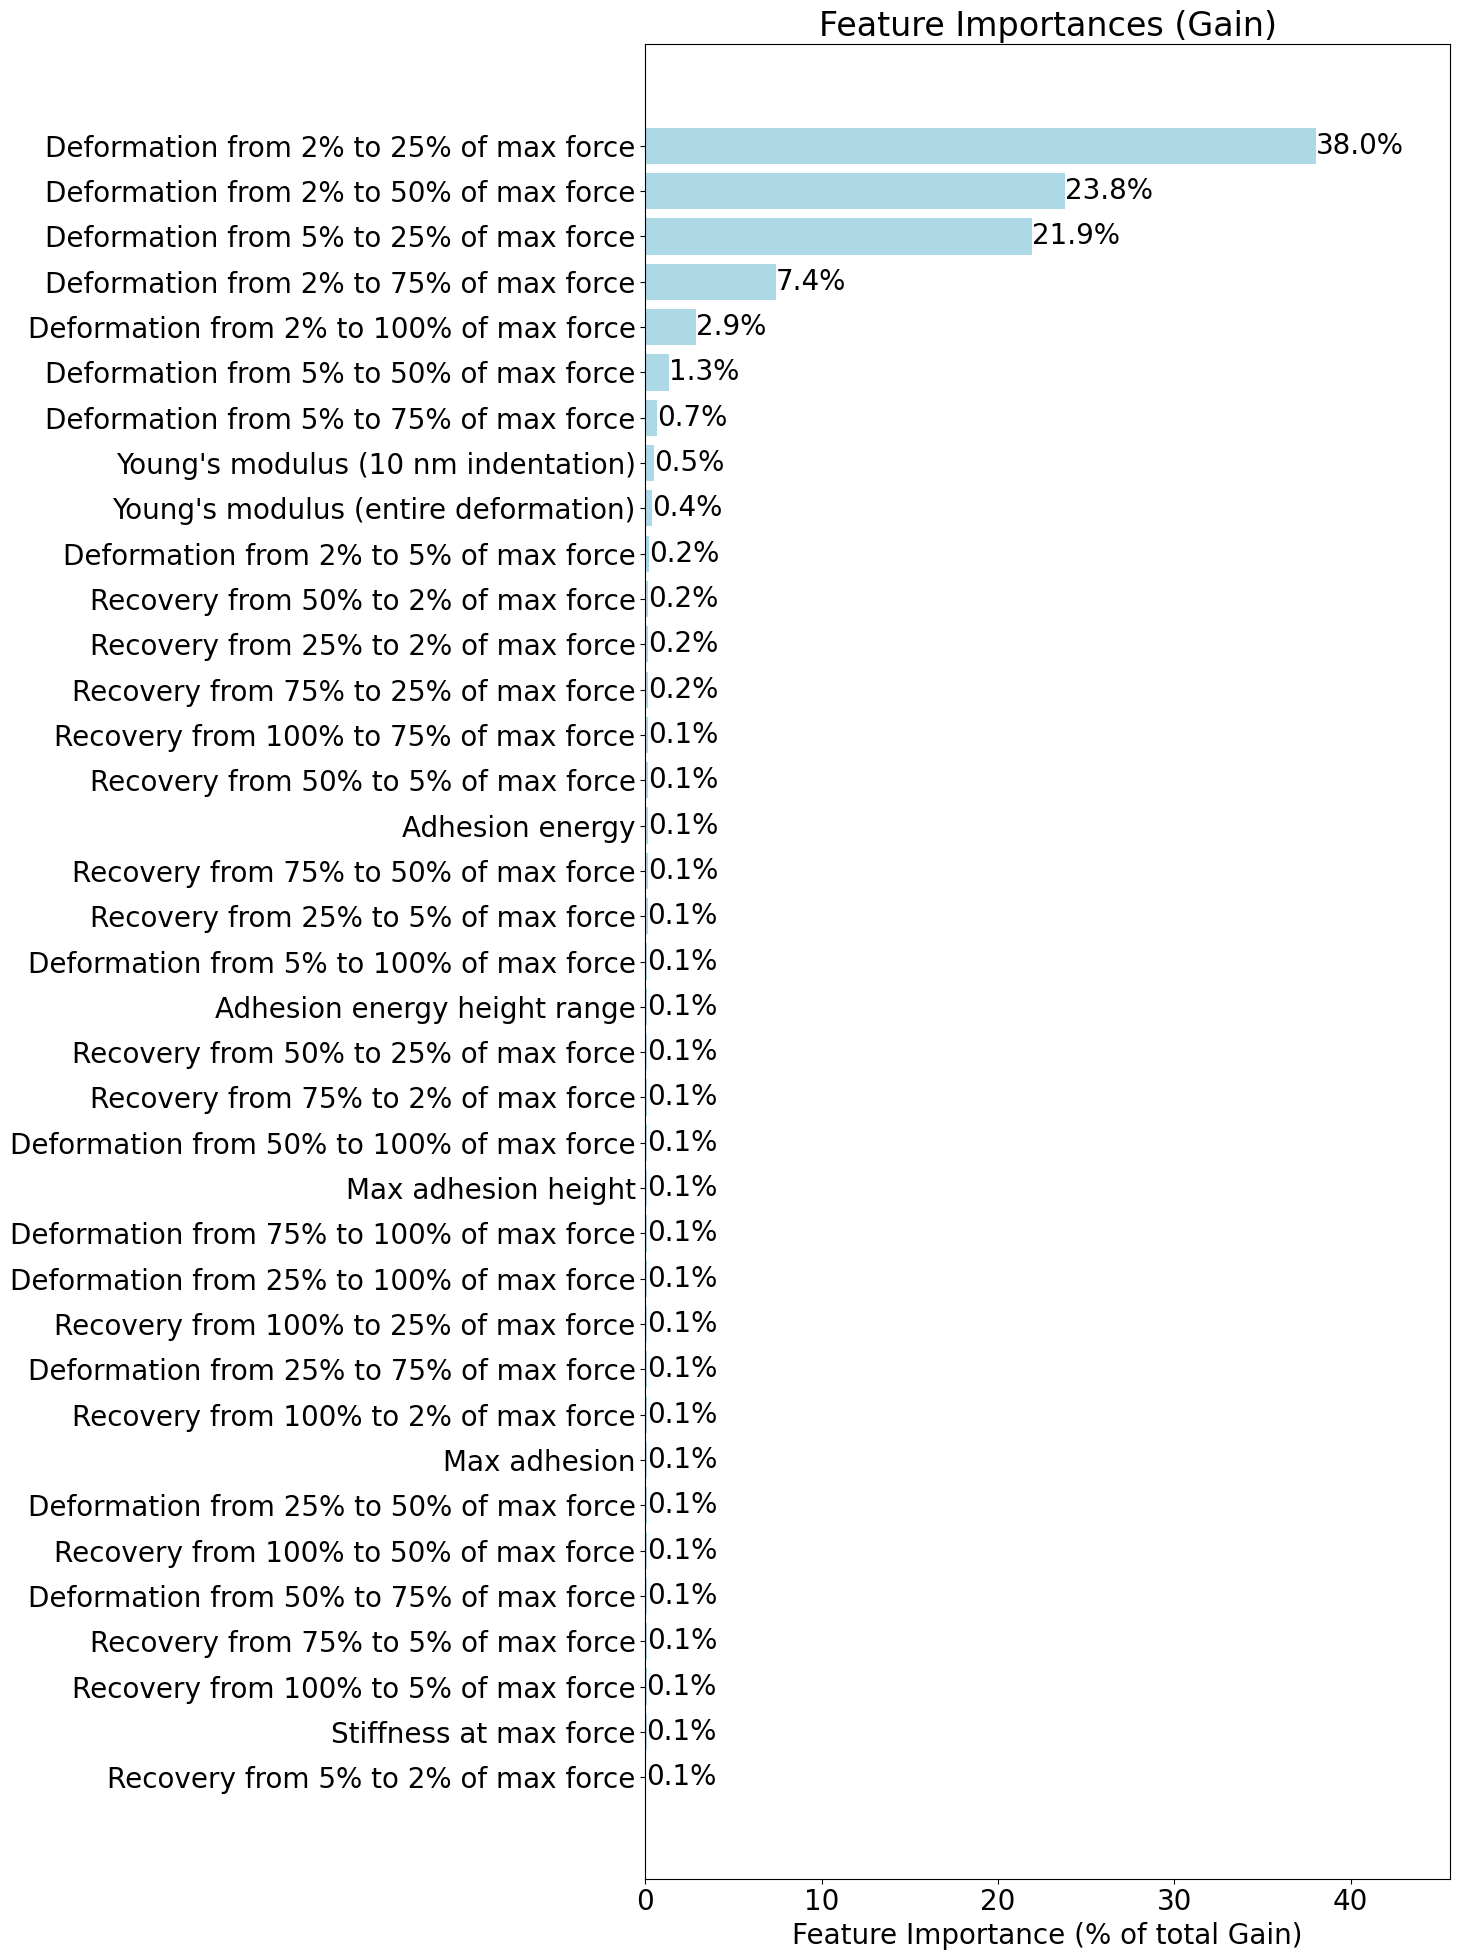

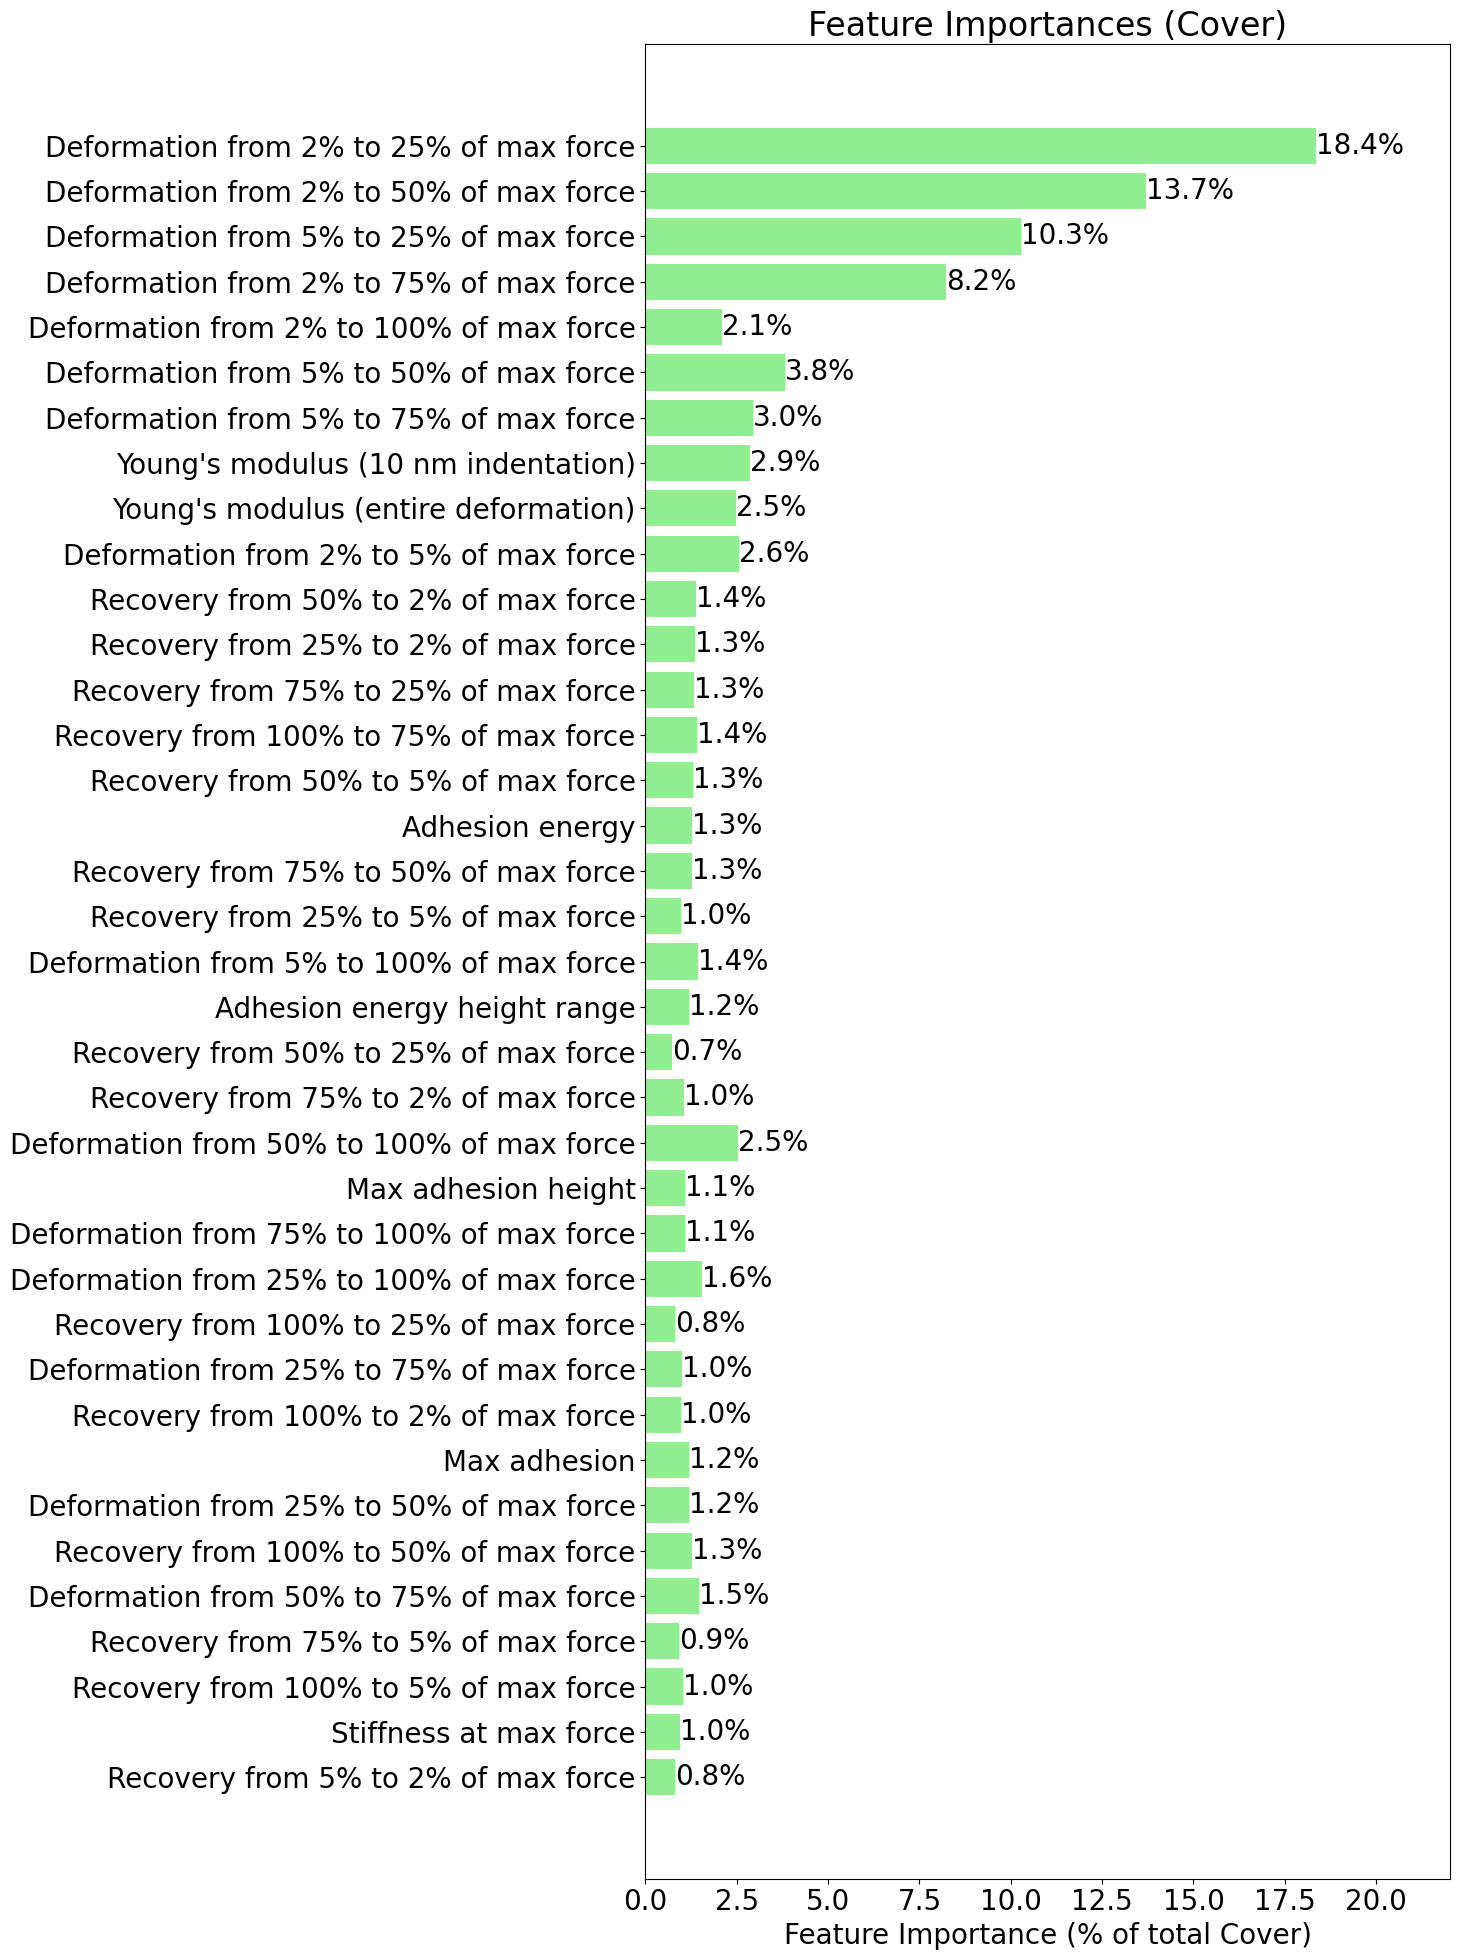

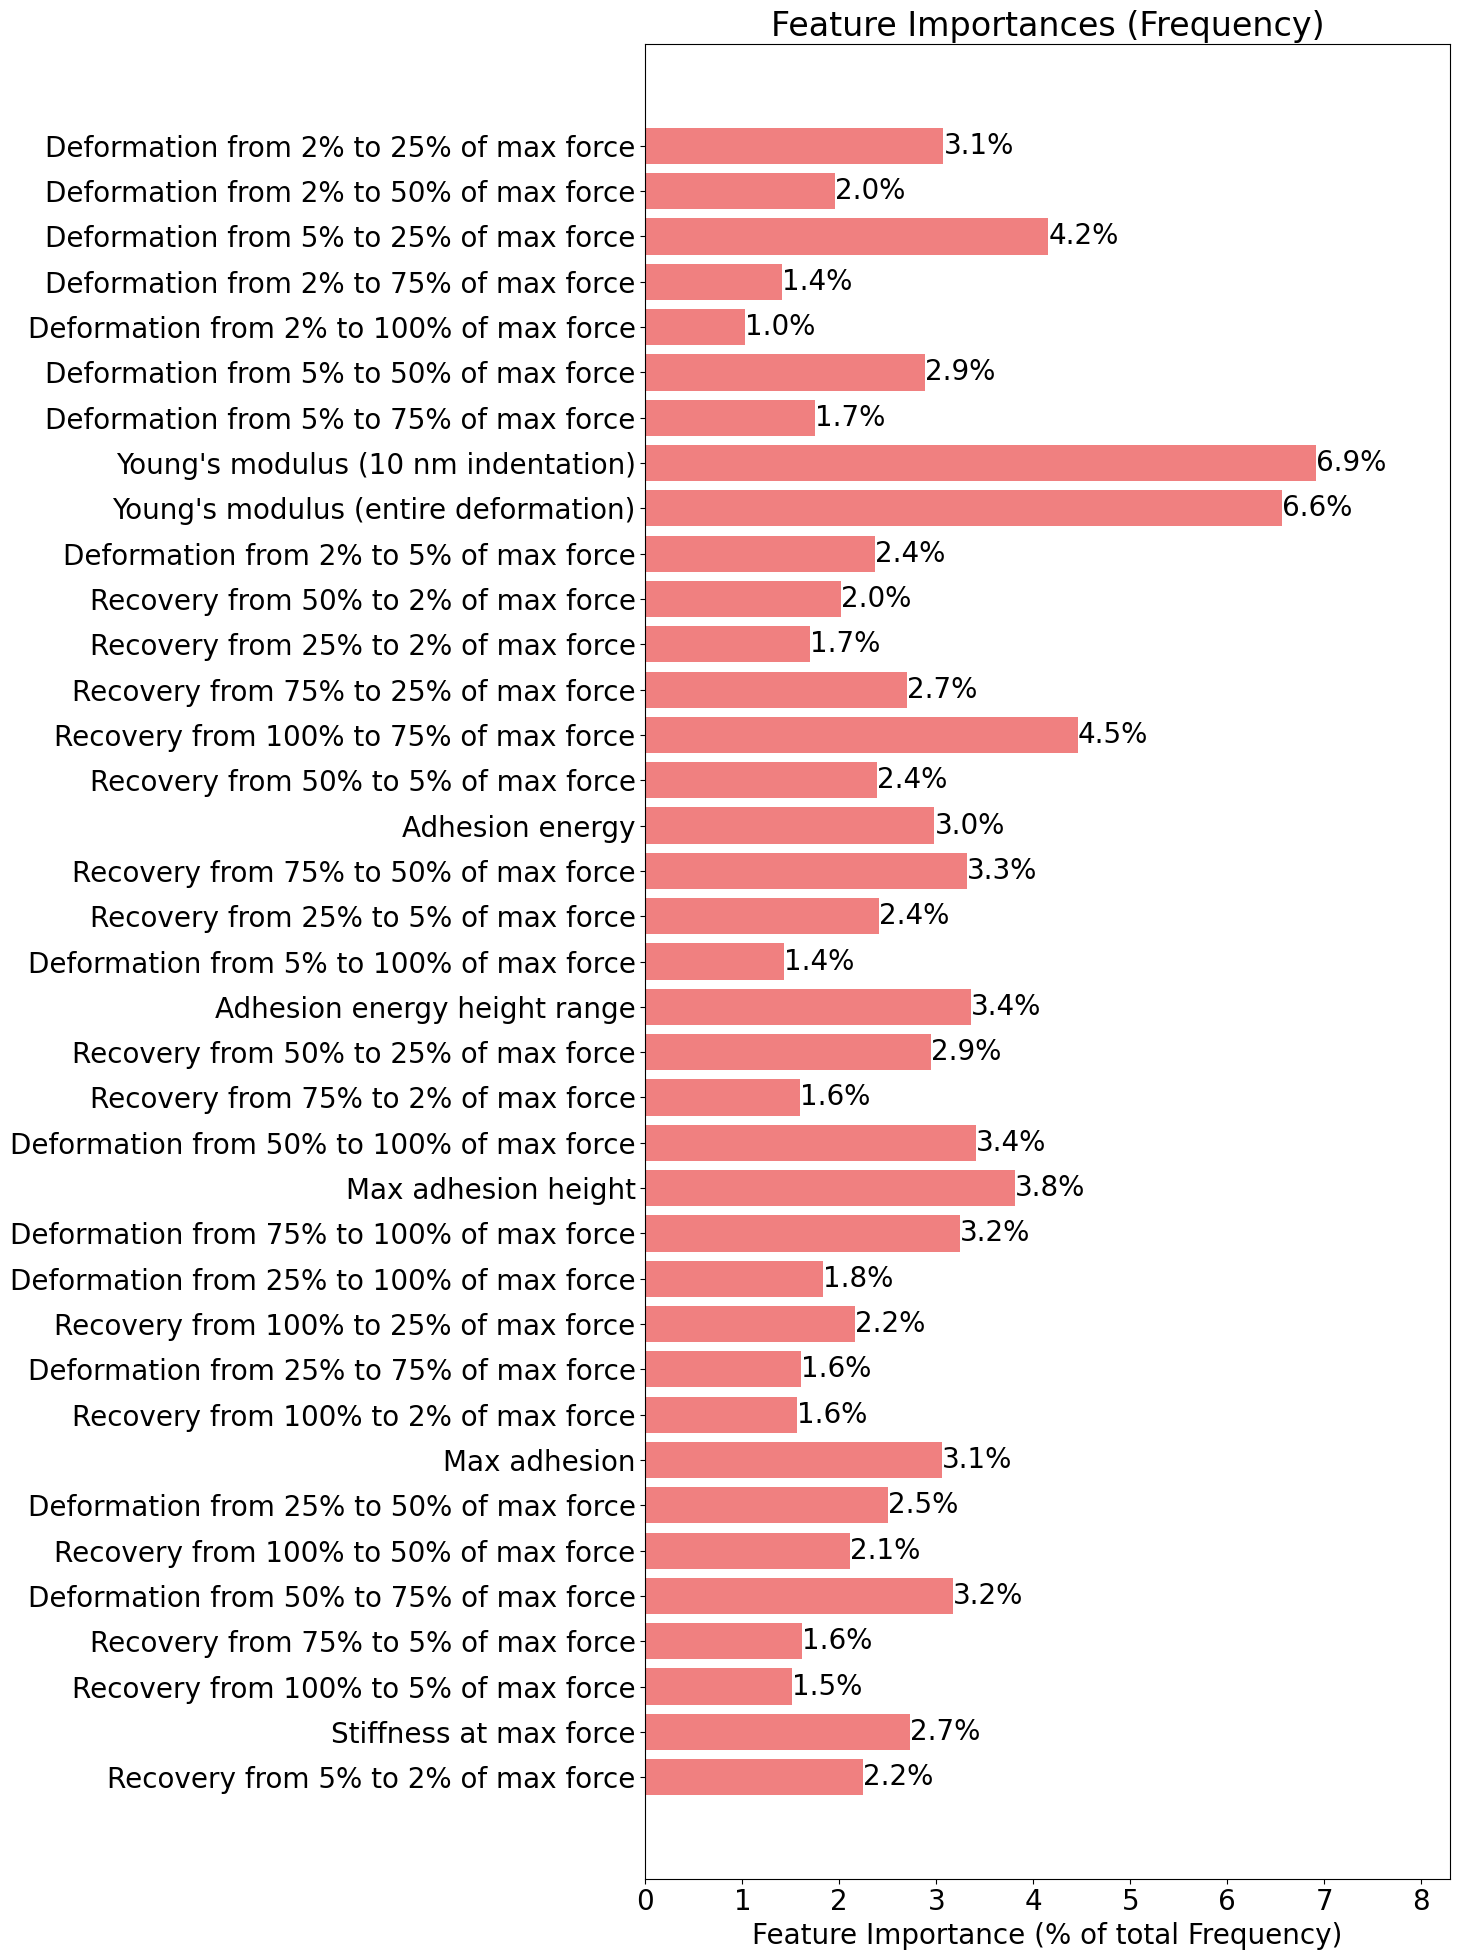

In [8]:
# Retrieve feature importance for Gain, Cover, and Frequency
booster = xgb_classifier_1.get_booster() # access the booster object
feature_importance_gain = booster.get_score(importance_type='gain') # retrieve the gain values 
feature_importance_cover = booster.get_score(importance_type='cover') # retrieve the cover values
feature_importance_frequency = booster.get_score(importance_type='weight') # retrieve the frequency values

# Create single DataFrame for all feature importance metrics
feature_importance_df = pd.DataFrame({
    'Feature': feature_importance_gain.keys(),
    'Gain': feature_importance_gain.values(),
    'Cover': feature_importance_cover.values(),
    'Frequency': feature_importance_frequency.values(),
})
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False) # Sort columns by Gain

# Plot Gain, Cover, and Frequency
plot_feature_importances(feature_importance_df, 'Gain', 'Gain')
plot_feature_importances(feature_importance_df, 'Cover', 'Cover', color='lightgreen')
plot_feature_importances(feature_importance_df, 'Frequency', 'Frequency', color='lightcoral')

### Evaluate the accuracy of the Particle/Substrate ML Classifier on the test data

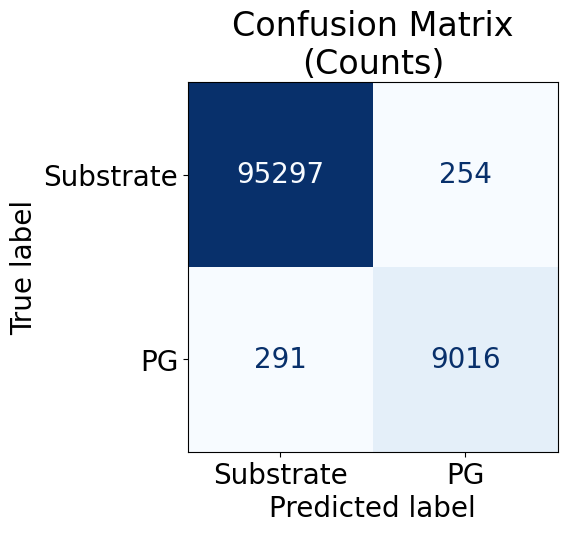

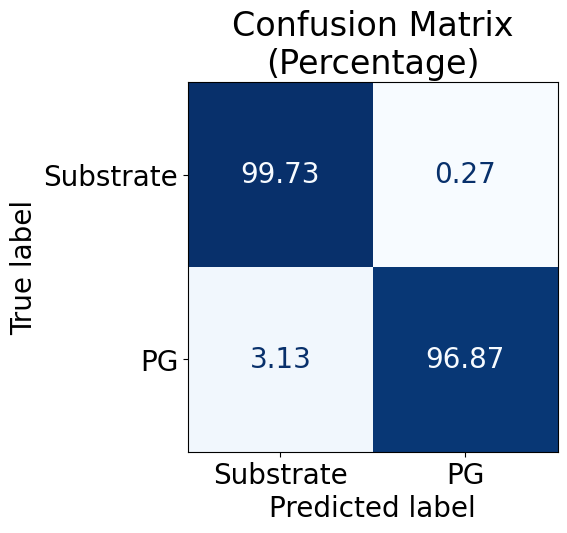

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     95551
           1       0.97      0.97      0.97      9307

    accuracy                           0.99    104858
   macro avg       0.98      0.98      0.98    104858
weighted avg       0.99      0.99      0.99    104858



In [9]:
# ----- Absolute Confusion Matrix -----#
cm_abs = confusion_matrix(y_test, y_pred_xgb)
disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=["Substrate", "PG"])
fig, ax = plt.subplots()
im = disp_abs.plot(cmap='Blues', ax=ax, colorbar=False).im_
plt.title('Confusion Matrix\n(Counts)')
plt.show()

# ----- Row-wise Percentage Confusion Matrix -----#
cm_norm = confusion_matrix(y_test, y_pred_xgb, normalize='true') * 100
disp_percent = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Substrate", "PG"])
fig, ax = plt.subplots()
im = disp_percent.plot(cmap='Blues', ax=ax, values_format=".2f", colorbar=False).im_
plt.title('Confusion Matrix\n(Percentage)')
plt.show()

print(classification_report(y_test, y_pred_xgb))

### Show the predicted output image from the particle/substrate classifier on the test/train dataset 

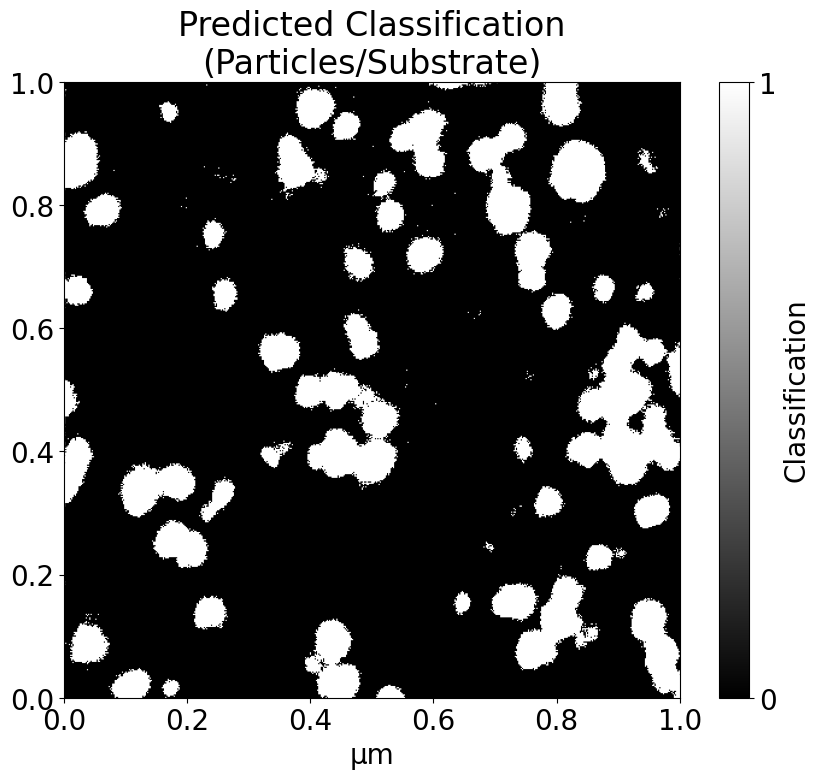

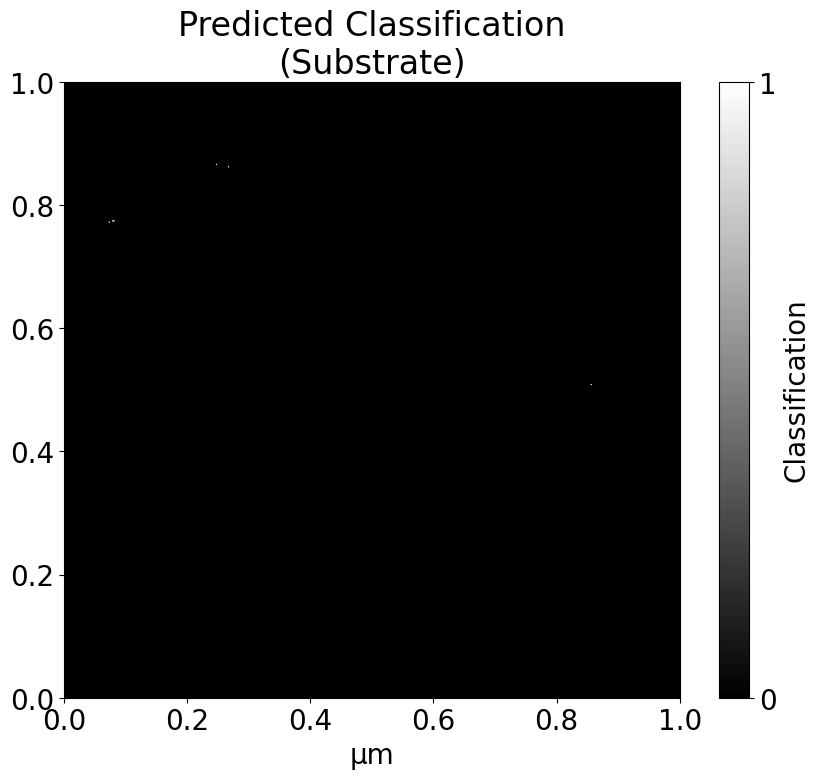

In [10]:
#----- Examne model on PG/Substrate Training Data -----#
# Scale the data using the same scaler as the trianing data
X_train_particles = df_data_train_particles.loc[:, selected_features]

# Fit data using the xgb model
y_pred_train_particles = xgb_classifier_1.predict(X_train_particles)

# Define the square image size
image_size = int(math.sqrt(len(X_train_particles)))

# Reshape the predicted output labels into an image
image_pred_train_particles = y_pred_train_particles.reshape(image_size, image_size)

# Plot the image
plot_afm_classification(
    image_pred_train_particles,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Particles/Substrate)"
)

#----- Examine Model on Substrate Training Data -----#
X_train_substrate = df_data_train_substrate.loc[:, selected_features]

# Fit data using xgb model
y_pred_train_substrate = xgb_classifier_1.predict(X_train_substrate)

# Define the square image size
image_size = int(math.sqrt(len(y_pred_train_substrate)))

# Reshape the predicted output labels into an image
image_pred_train_substrate = y_pred_train_substrate.reshape(image_size, image_size)

# Plot the image
plot_afm_classification(
    image_pred_train_substrate,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Substrate)"
)

### Remove small clusters from particle/substrate image

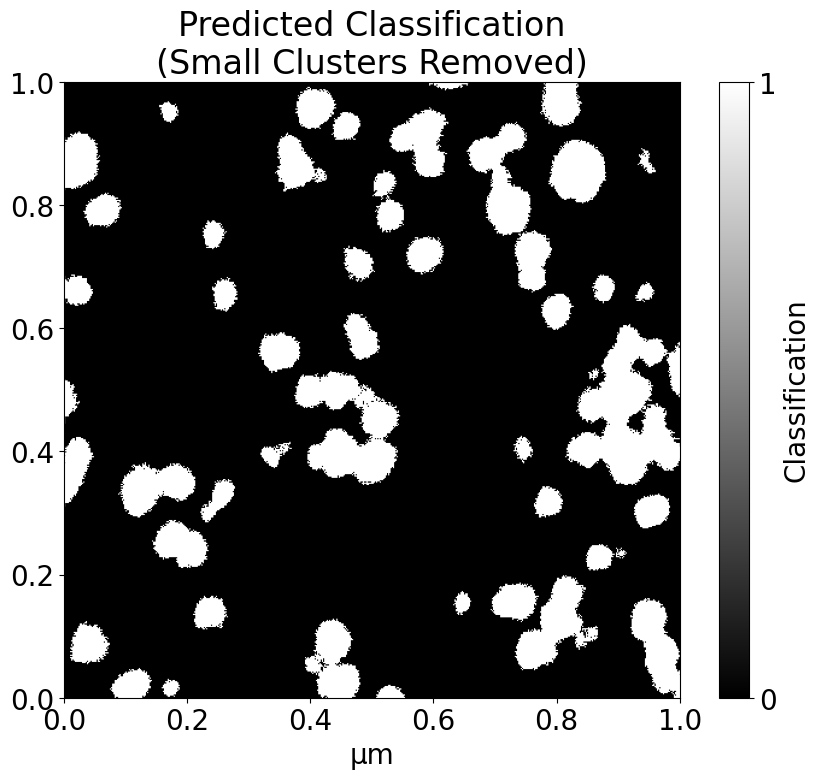

Total number of pixels with value 1 before changes: 46293
Total number of pixels whose values were changed: 377
Percent of PG pixels changed: 0.8143779837124403%


In [11]:
# Set the maximum number of pixels in a cluster to remove
threshold = 35 

# Define the image of interest
image = image_pred_train_particles

# Create a copy of the image
new_image_training_particles = np.copy(image)

# Label regions of connected pixels with values > 1 (i.e. not the substrate)
labeled_image = label(new_image_training_particles)

# Get properties of each connected region
regions = regionprops(labeled_image)

# Iterate through each region and examine area of region
# If region area is less than threshold change classification value to 0
for region in regions:
     if region.area < threshold:
        for coord in region.coords:
            new_image_training_particles[coord[0], coord[1]] = 0
                          
# Plot the new image
plot_afm_classification(
    new_image_training_particles,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Small Clusters Removed)"
)

# Calculate the total number of pixels with value 1 in the original image
total_white_pixels = np.sum(image == 1)

# Calculate the total number of changed pixels
changed_pixels = np.sum(image != new_image_training_particles)

# Calculate the percent of changed pixels in terms of all PG pixels
changed_pixels_percent = 100*changed_pixels/total_white_pixels

# Print the results of the changes
print(f"Total number of pixels with value 1 before changes: {total_white_pixels}")
print(f"Total number of pixels whose values were changed: {changed_pixels}")
print(f"Percent of PG pixels changed: {changed_pixels_percent}%")

## Inner Particle Structure ML Classifer

### Create DataFrame of selected feature values for each force-distance curve within particles only

In [12]:
# Manual labels are 0, 1, or 2 to indicate substrate, outer region, inner region respectively
# Import manual classification labels
y_2 = df_data_train_particles[target_feature].copy()
# Create mask from manually labelled particles
mask = (y_2 != 0)
# Import data from particle/substrate image
X_2 = df_data_train_particles.loc[:, selected_features]
# Use mask to filter data to include only that manually labelled as corresponding to particles
X_train_filtered = X_2[mask]
y_train_filtered = y_2[mask]
# Change binary classification for outer and inner regions to 0 and 1, respectively
y_train_filtered = y_train_filtered - 1

### Train/Test the Internal Particle Structure ML Classifier

In [13]:
# Train-test split with 90% of the data for training
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_train_filtered, y_train_filtered, test_size = 0.1, random_state = 17)

# Construct XGBoost classifier
xgb_classifier_2 = xgb.XGBClassifier(
    n_estimators=800,      # set the number of decision trees
    learning_rate=0.03,    # set learning rate, keep small to improve generalization
    max_depth=5,           # set maximum depth of each decision tree, keep small to improve generalization
    min_child_weight=5,    # set minimum sum of instance weights, avoid splits on small/noisy data
    subsample=0.7,         # set percent of data per tree for randomness
    colsample_bytree=0.7,  # set percent of features per tree to reduce feature reliance
    gamma=0.5,             # set minimum loss reduction needed for a split
    reg_alpha=0.05,        # set L1 regularization (lasso), penalty for features with very small weights, promote meaningful features
    reg_lambda=5,          # set L2 regularization (ridge), penalty for features with large weights, promote generalization
    random_state=17        # set the initial state for reproducibility
)

# Train the classifier
xgb_classifier_2.fit(X_train_2, y_train_2)

# Predict on the test set
y_pred_xgb_2 = xgb_classifier_2.predict(X_test_2)

# Display the number of pixels classified in the training set
print("Total Pixels Classified:", len(y_train_2))

# Evaluate the classifier
accuracy_xgb_2 = accuracy_score(y_test_2, y_pred_xgb_2)
print("XGBoost Testing Accuracy:", accuracy_xgb_2)

# Display the type of objective function used
print("Objective function used: ", xgb_classifier_2.get_params()["objective"])


print('Inner Particle Structure ML Classifier sucessfully trained')

Total Pixels Classified: 41815
XGBoost Testing Accuracy: 0.8601248117064773
Objective function used:  binary:logistic
Inner Particle Structure ML Classifier sucessfully trained


### View Feature Importance In detail

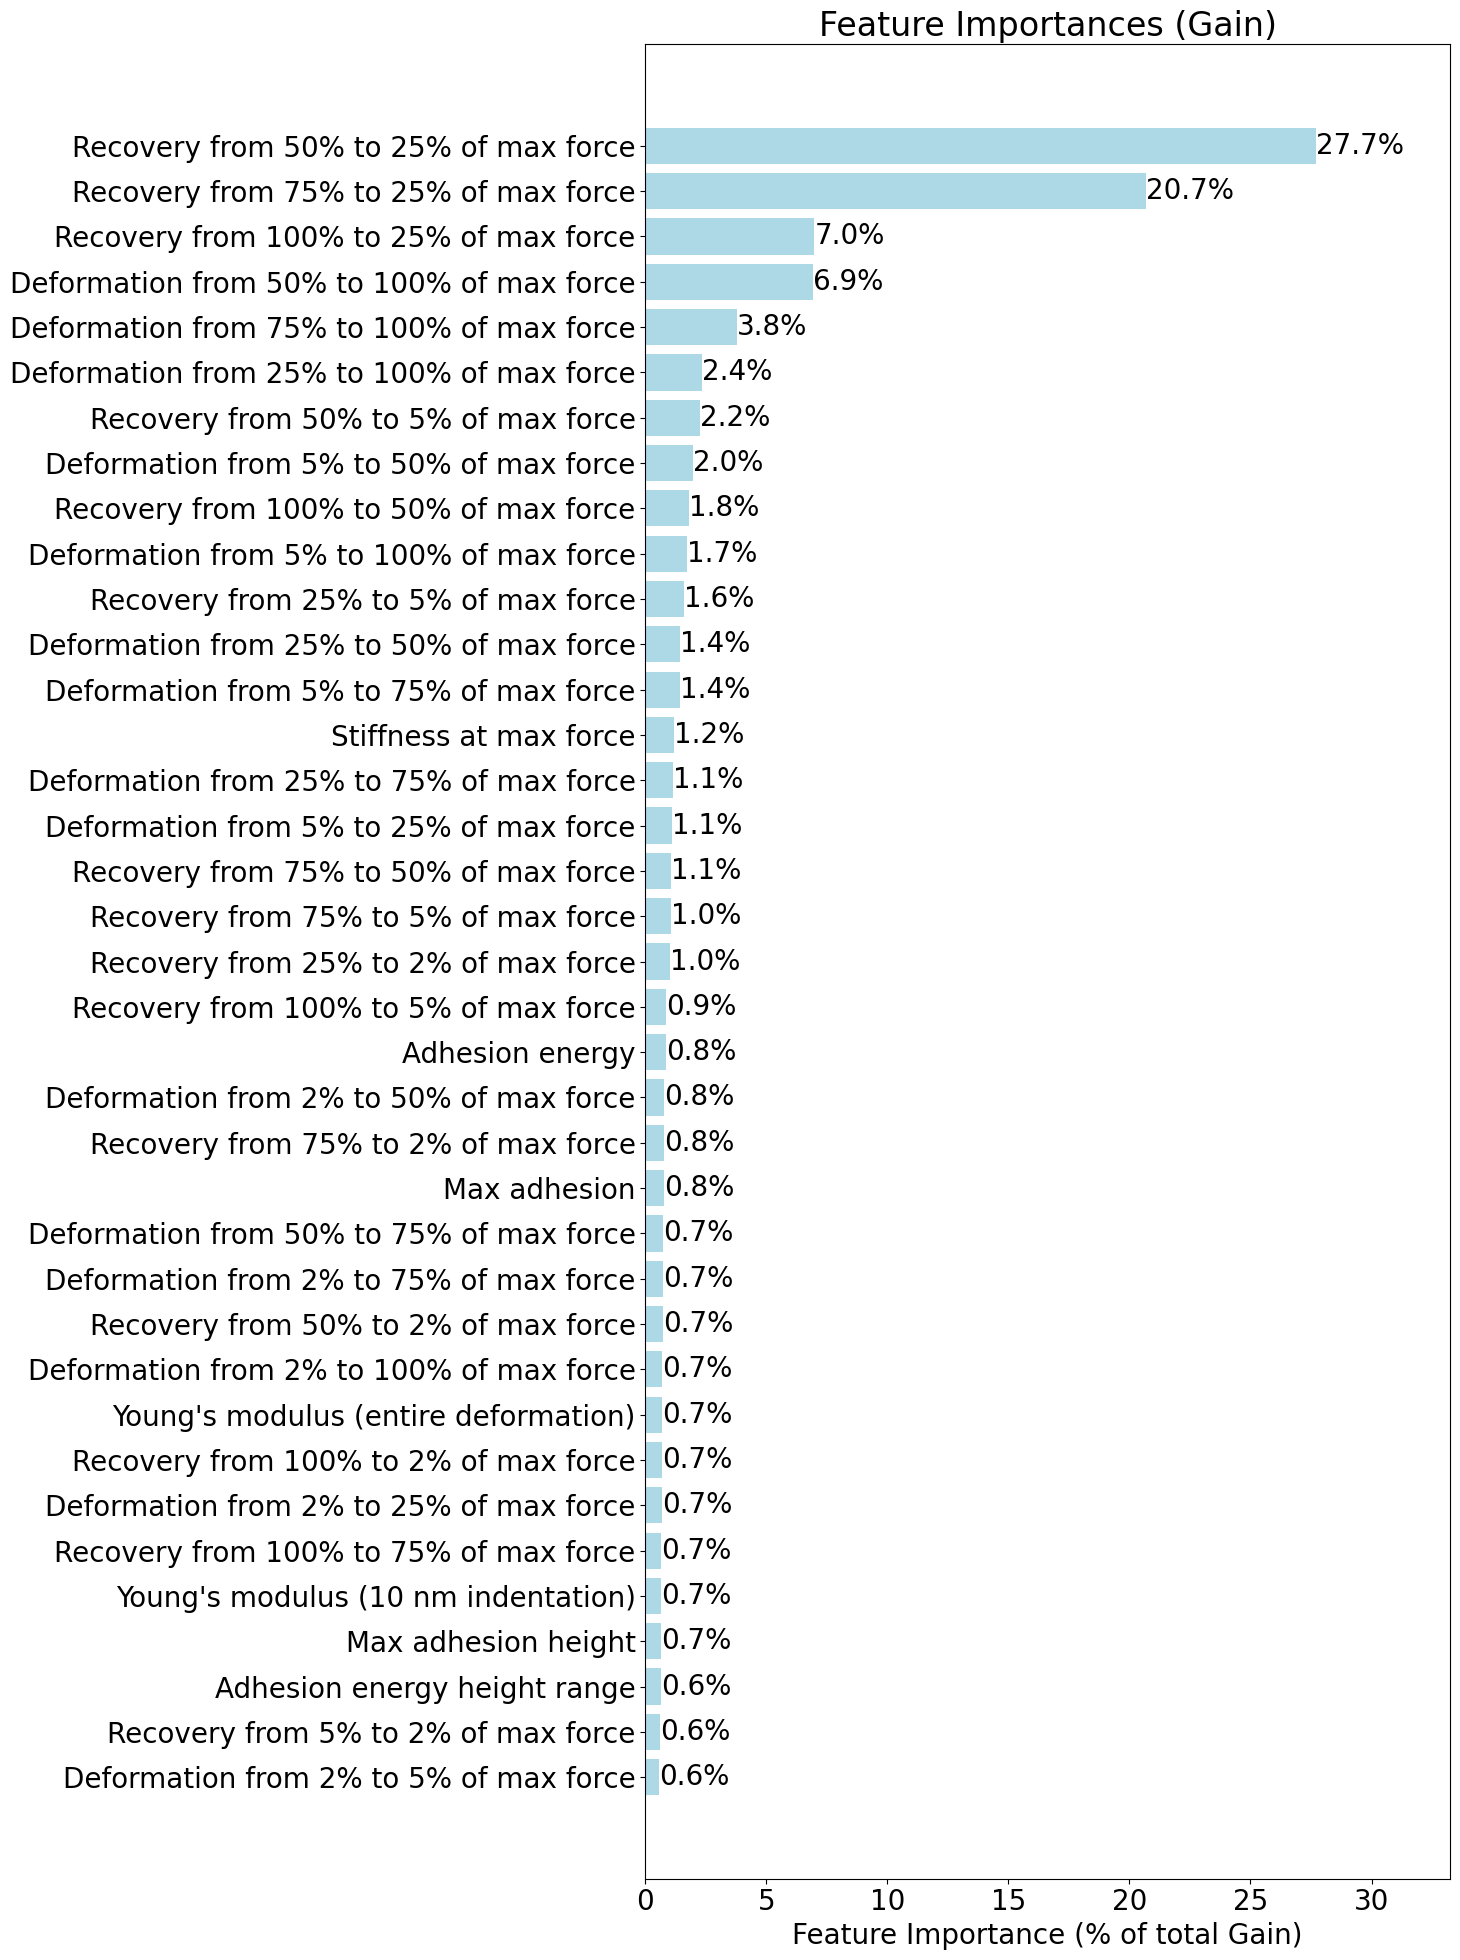

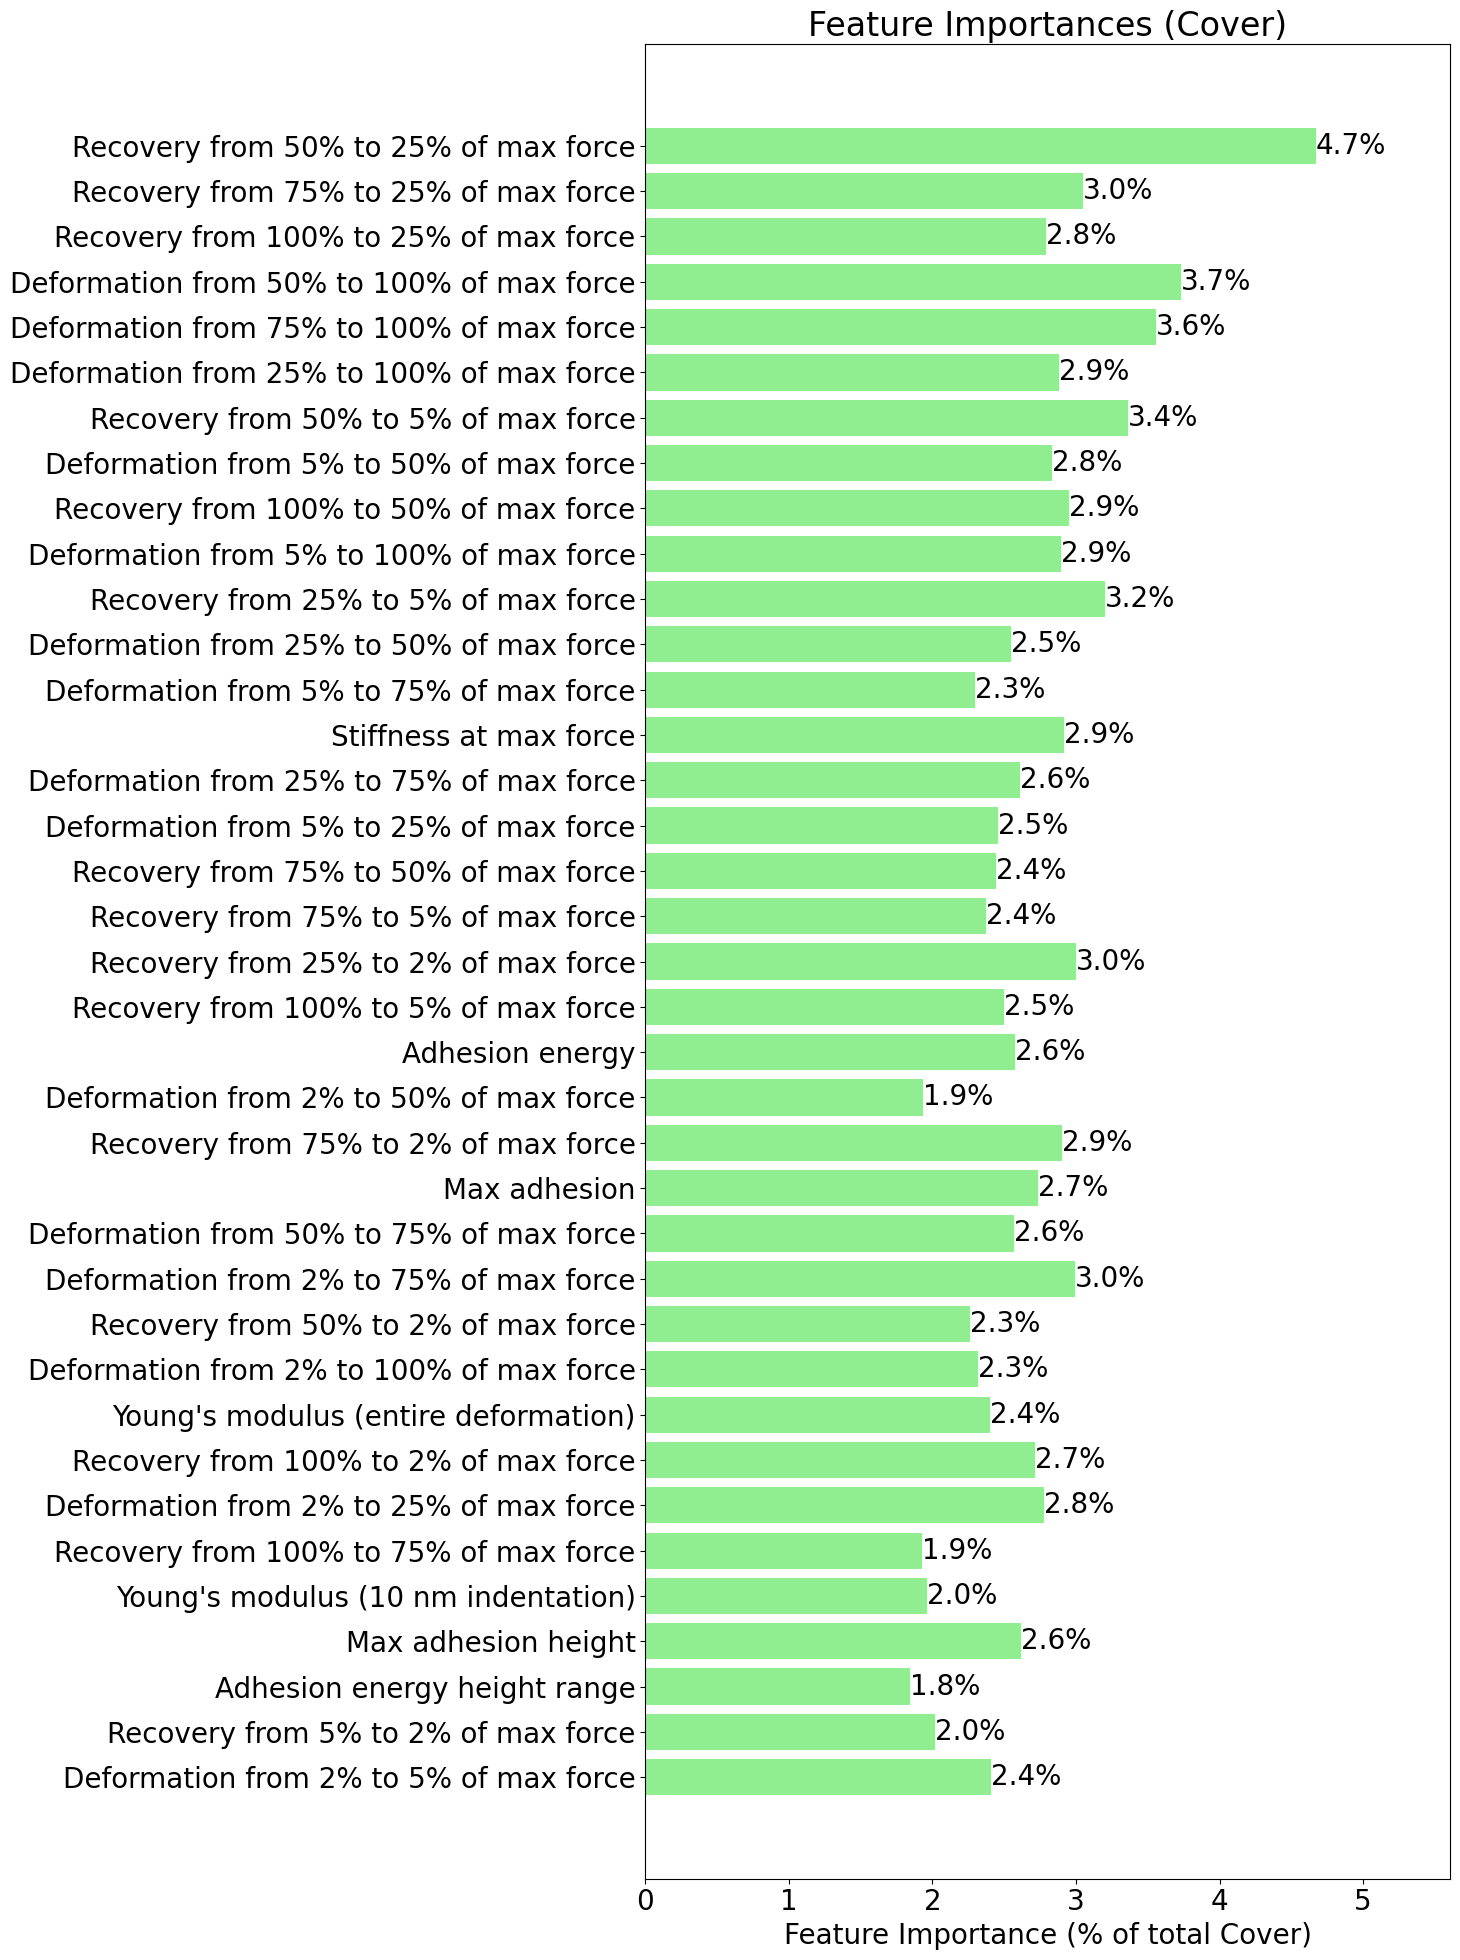

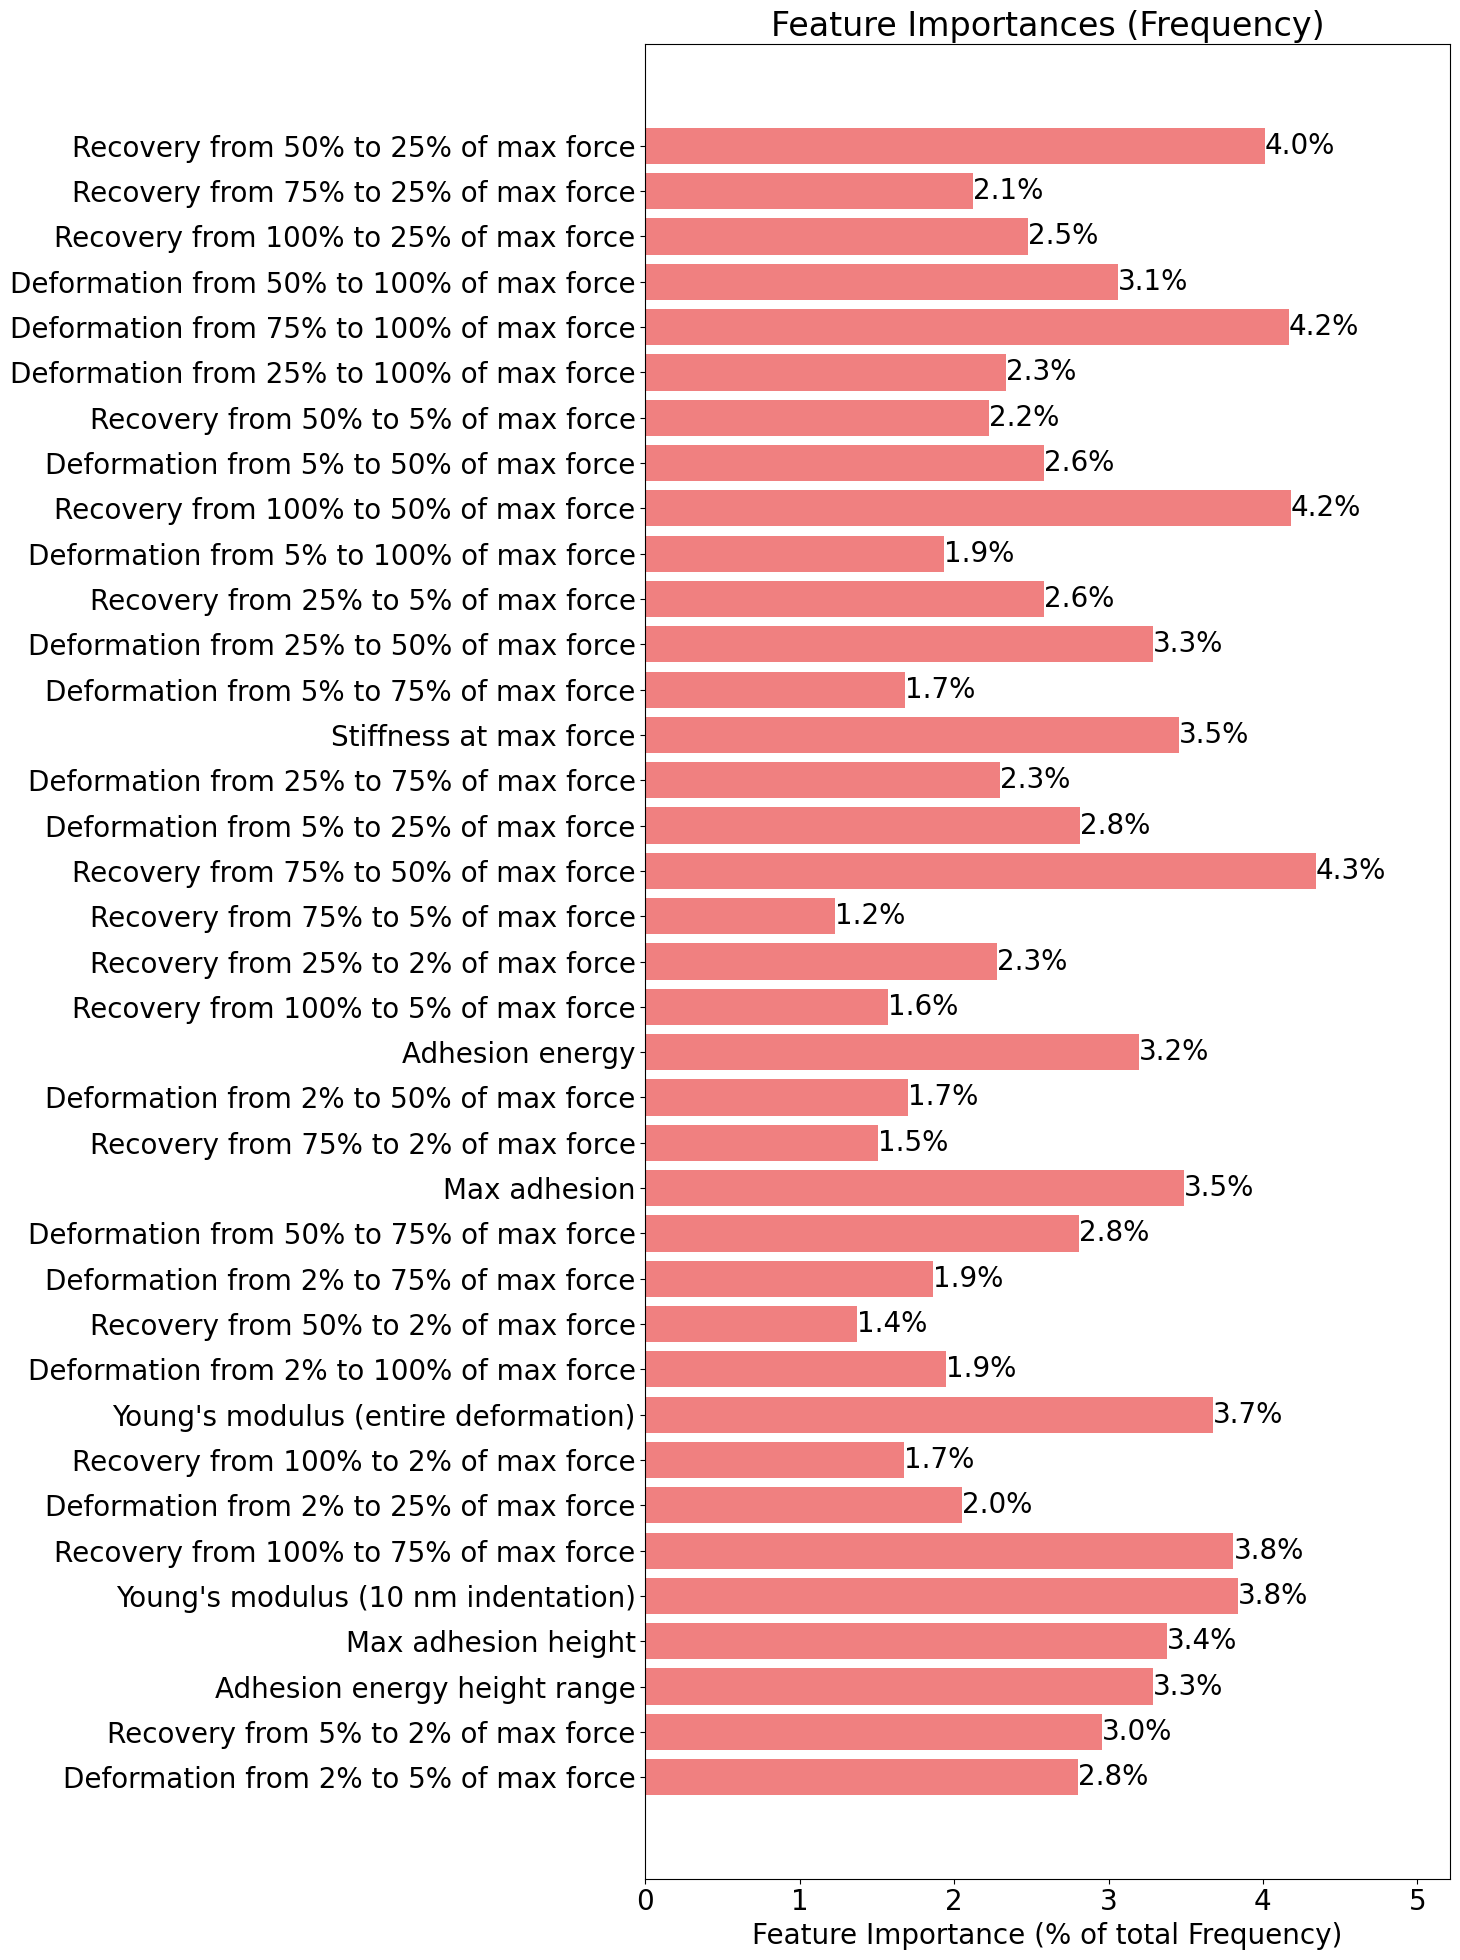

In [14]:
# Retrieve feature importance for Gain, Cover, and Frequency
booster = xgb_classifier_2.get_booster() # Access the booster object
feature_importance_gain_2 = booster.get_score(importance_type='gain') # retrieve the gain values 
feature_importance_cover_2 = booster.get_score(importance_type='cover') # retrieve the cover values 
feature_importance_frequency_2 = booster.get_score(importance_type='weight') # retrieve the frequency values 

# Convert to DataFrame for easy visualization
feature_importance_internal_df = pd.DataFrame({
    'Feature': feature_importance_gain_2.keys(),
    'Gain': feature_importance_gain_2.values(),
    'Cover': feature_importance_cover_2.values(),
    'Frequency': feature_importance_frequency_2.values(),
})

# Sort by Gain for consistency
feature_importance_internal_df = feature_importance_internal_df.sort_values(by='Gain', ascending=False)

# Plot Gain, Cover, and Frequency
plot_feature_importances(feature_importance_internal_df, 'Gain', 'Gain')
plot_feature_importances(feature_importance_internal_df, 'Cover', 'Cover', color='lightgreen')
plot_feature_importances(feature_importance_internal_df, 'Frequency', 'Frequency', color='lightcoral')

### Evaluate the accuracy of the Inner Particle Structure ML Classifier on the test data

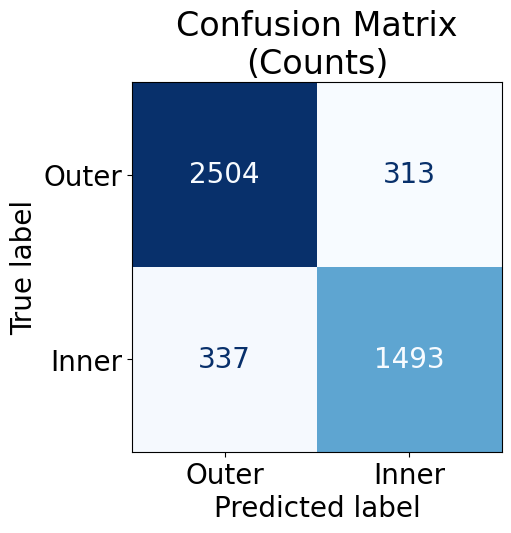

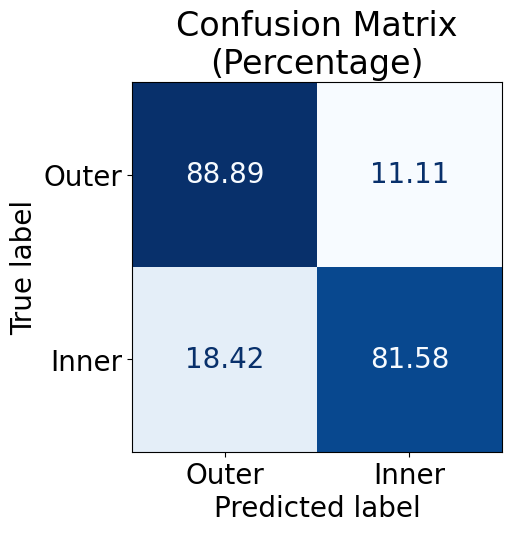

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      2817
           1       0.83      0.82      0.82      1830

    accuracy                           0.86      4647
   macro avg       0.85      0.85      0.85      4647
weighted avg       0.86      0.86      0.86      4647



In [15]:
# ----- Absolute Confusion Matrix -----#
cm_abs_2 = confusion_matrix(y_test_2, y_pred_xgb_2)
disp_abs_2 = ConfusionMatrixDisplay(confusion_matrix=cm_abs_2, display_labels=["Outer", "Inner"])
fig, ax = plt.subplots()
im = disp_abs_2.plot(cmap='Blues', ax=ax, colorbar=False).im_
plt.title('Confusion Matrix\n(Counts)')
plt.show()

# ----- Row-wise Percentage Confusion Matrix -----#
cm_norm_2 = confusion_matrix(y_test_2, y_pred_xgb_2, normalize='true') * 100
disp_percent_2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm_2, display_labels=["Outer", "Inner"])
fig, ax = plt.subplots()
im = disp_percent_2.plot(cmap='Blues', ax=ax, values_format=".2f", colorbar=False).im_
plt.title('Confusion Matrix\n(Percentage)')
plt.show()

print(classification_report(y_test_2, y_pred_xgb_2))

### Show the predicted output image from the Inner Particle Structure ML classifier on the test/train dataset 

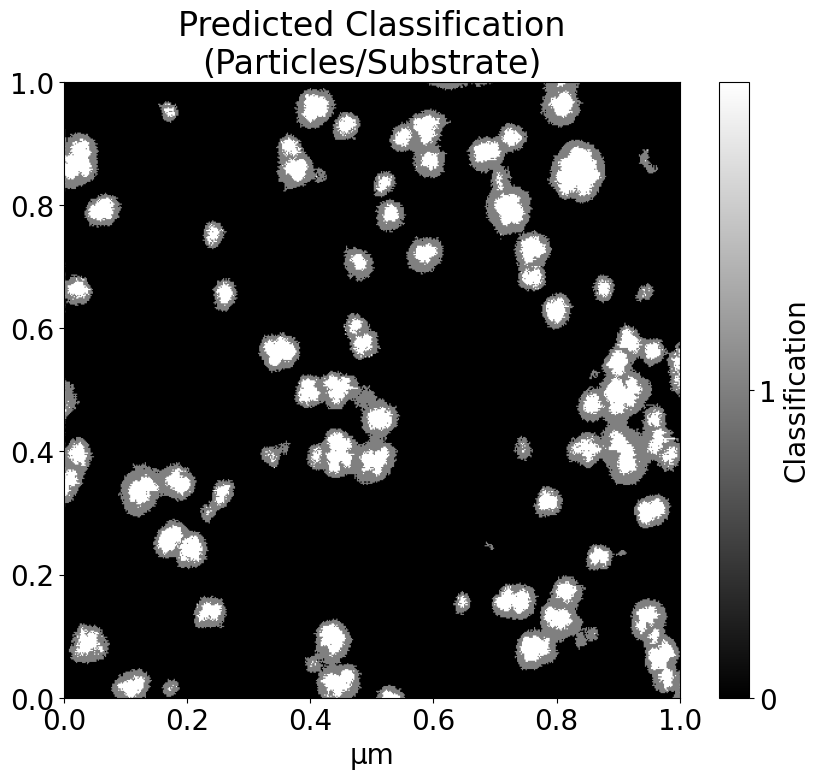

In [16]:
# Fit particle regions in test/train data using trained Inner Particle Structure ML Classifier
y_pred_train_particles_filtered = xgb_classifier_2.predict(X_train_filtered)

# Update the predicted regions to include the results of the second classifier
X_train_particles_labels = df_data_train_particles['label']
y_pred_train_particles_filtered = y_pred_train_particles_filtered + 1 #change outer particle region to values of 1 and inner region to values of 2
y_pred_train_particles_filtered_combined = np.copy(X_train_particles_labels) # copy the output from the first classifier
y_pred_train_particles_filtered_combined[mask] = y_pred_train_particles_filtered # update the pixels according to the second clssifier

# Define the image size
image_size = int(math.sqrt(len(X_train_particles))) # assuming a square image
# Reshape the predicted output labels into an image
image_pred_train_particles_filtered = y_pred_train_particles_filtered_combined.reshape(image_size, image_size)

# Plot the image
plot_afm_classification(
    image_pred_train_particles_filtered,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Particles/Substrate)"
)

## Save Trained Supervised ML Classifiers and Feature List

In [17]:
# Create the full file path
model_1_filename = os.path.join(output_folder, 'xgb_classifier_particle_substrate.pkl')
model_2_filename = os.path.join(output_folder, 'xgb_classifier_inner_particle_structure.pkl')

# Save the classifier
joblib.dump(xgb_classifier_1, model_1_filename)
joblib.dump(xgb_classifier_2, model_2_filename)

print(f"Supervised ML classifiers saved to: {output_folder}")

# Save selected features
features_filename = os.path.join(output_folder, 'xgb_selected_features.json')
with open(features_filename, 'w') as f:
    json.dump(selected_features, f)

print(f"Selected features saved to: {output_folder}")



# Calculate the total run time
end_time = time.time()
elapsed_time = end_time - start_time

print("Total Run Time = ", elapsed_time, "seconds")

Supervised ML classifiers saved to: .
Selected features saved to: .
Total Run Time =  55.298837184906006 seconds
